# Exercise P3: Noise Type Detector & Filter

**Design Challenge:** Build a tool that **automatically identifies** noise type and applies the optimal filter.

| Bước | Mô tả |
|------|-------|
| 1 | **Generate** ảnh nhiễu (Gaussian & Salt-and-Pepper) |
| 2 | **Detect** loại nhiễu tự động (histogram + statistics) |
| 3 | **Filter** tự động theo loại nhiễu phát hiện |
| 4 | **Report** PSNR trước/sau lọc + visualization |

## 0. Import thư viện

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats as sp_stats
from pathlib import Path

print("OpenCV version:", cv2.__version__)
print("NumPy  version:", np.__version__)

OpenCV version: 4.12.0
NumPy  version: 2.1.3


---
## 1. Tạo ảnh nhiễu 

Module này cung cấp hàm thêm **Gaussian noise** và **Salt-and-Pepper noise** vào ảnh grayscale.

In [2]:
# ─────────────────────────────────────────────
# 1a. Gaussian noise
# ─────────────────────────────────────────────

def add_gaussian_noise(img, std=25):
    """Thêm Gaussian noise với độ lệch chuẩn `std`."""
    noise = np.random.normal(0, std, img.shape)
    noisy = img.astype(np.float32) + noise
    return np.clip(noisy, 0, 255).astype(np.uint8)


# ─────────────────────────────────────────────
# 1b. Salt-and-Pepper noise (chuẩn cho detector)
# ─────────────────────────────────────────────

def add_salt_pepper_noise_strong(img, amount=0.05):
    """
    Thêm Salt-and-Pepper noise theo cách chắc chắn tạo ra pixel cực trị
    KHÁC RÕ so với lân cận (để detector nhận diện đúng).
    """
    noisy = img.copy()
    h, w = img.shape
    num_pixels = int(amount * h * w)

    coords_added = 0
    while coords_added < num_pixels:
        i = np.random.randint(1, h - 1)
        j = np.random.randint(1, w - 1)

        patch = img[i-1:i+2, j-1:j+2]
        median_val = np.median(patch)

        if abs(median_val - 0) > 50:
            noisy[i, j] = 0       # pepper
            coords_added += 1
        elif abs(median_val - 255) > 50:
            noisy[i, j] = 255     # salt
            coords_added += 1

    return noisy


print("✓ Hàm add_gaussian_noise và add_salt_pepper_noise_strong đã sẵn sàng.")

✓ Hàm add_gaussian_noise và add_salt_pepper_noise_strong đã sẵn sàng.


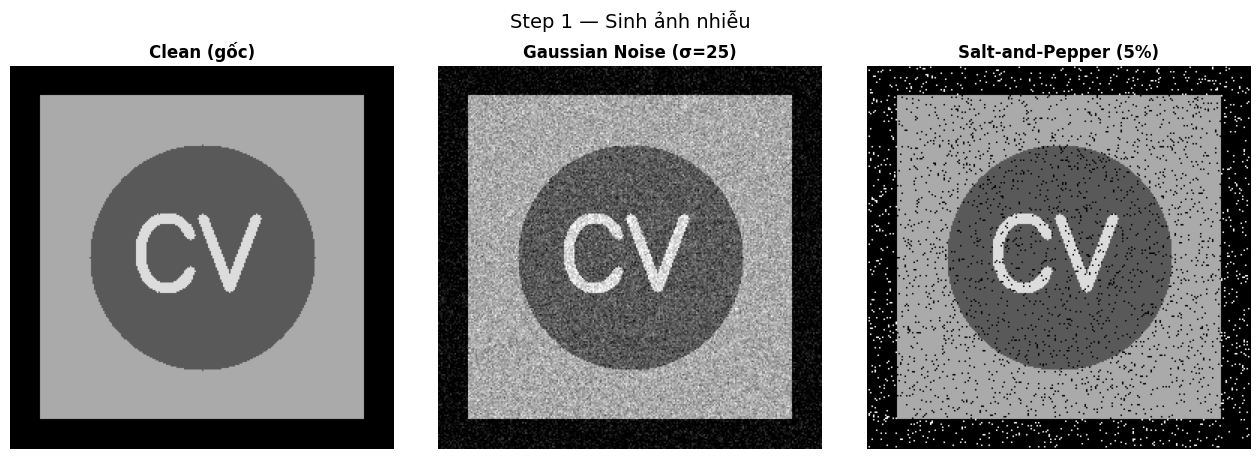

Saved: step1_noisy_images.png


In [3]:
# ─────────────────────────────────────────────
# 1c. Tạo ảnh sạch & sinh ảnh nhiễu
# ─────────────────────────────────────────────

# Ảnh sạch tổng hợp (nếu không có file ảnh thực)
clean = np.zeros((256, 256), dtype=np.uint8)
cv2.rectangle(clean, (20, 20), (235, 235), 170, -1)
cv2.circle(clean, (128, 128), 75, 90, -1)
cv2.putText(clean, "CV", (80, 148), cv2.FONT_HERSHEY_SIMPLEX, 2.2, 220, 5)

# Sinh ảnh nhiễu
np.random.seed(42)
noisy_gaussian = add_gaussian_noise(clean, std=25)
noisy_sp       = add_salt_pepper_noise_strong(clean, amount=0.05)

# Hiển thị
fig, axes = plt.subplots(1, 3, figsize=(13, 4.5))
for ax, img, title in zip(axes,
    [clean, noisy_gaussian, noisy_sp],
    ["Clean (gốc)", "Gaussian Noise (σ=25)", "Salt-and-Pepper (5%)"]):
    ax.imshow(img, cmap="gray", vmin=0, vmax=255)
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.axis("off")

plt.suptitle("Step 1 — Sinh ảnh nhiễu", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig("step1_noisy_images.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: step1_noisy_images.png")

---
## 2. Phát hiện loại nhiễu tự động — `noise_detector_filter.py`

Phân tích ảnh qua:
- **Residual** (ảnh trừ bản làm mượt nhẹ) → tính kurtosis, skewness
- **Outlier ratio** (tỉ lệ pixel = 0 hoặc 255)
- **True S&P ratio** (pixel cực trị khác mạnh với median lân cận 3×3)

| Điều kiện | Kết luận |
|-----------|----------|
| `true_sp_ratio > 0.02` | Salt-and-Pepper |
| `\|kurtosis\| < 3.5` và `\|skewness\| < 1.0` | Gaussian |
| Còn lại | Other |

In [4]:
def detect_noise_type(gray: np.ndarray) -> dict:
    """
    Phân tích ảnh grayscale và phân loại loại nhiễu.
    Trả về dict chứa noise_type và các thống kê.
    """
    # Ước lượng nhiễu = ảnh - phiên bản làm mượt nhẹ
    blurred  = cv2.GaussianBlur(gray.astype(np.float32), (5, 5), 1.0)
    residual = gray.astype(np.float32) - blurred

    kurtosis = float(sp_stats.kurtosis(residual.ravel()))
    skewness = float(sp_stats.skew(residual.ravel()))
    std_res  = float(residual.std())

    # Tỉ lệ pixel cực trị 0 hoặc 255
    outlier_mask  = (gray == 0) | (gray == 255)
    outlier_ratio = float(outlier_mask.mean())

    # Sai lệch so với median lân cận 3x3
    median_local = cv2.medianBlur(gray, 3).astype(np.float32)
    mean_diff    = float(np.abs(gray.astype(np.float32) - median_local).mean())

    # Pixel cực trị VÀ khác mạnh với lân cận → true S&P
    diff_map      = np.abs(gray.astype(np.float32) - median_local)
    true_sp_mask  = outlier_mask & (diff_map > 50)
    true_sp_ratio = float(true_sp_mask.mean())

    # Phân loại
    if true_sp_ratio > 0.02:
        noise_type = "salt_and_pepper"
        reasoning  = (f"true_sp_ratio={true_sp_ratio:.4f} > 0.02 "
                      f"→ Salt-and-Pepper")
    elif abs(kurtosis) < 3.5 and abs(skewness) < 1.0:
        noise_type = "gaussian"
        reasoning  = (f"kurtosis={kurtosis:.2f} ∈ (-3.5, 3.5) và "
                      f"skewness={skewness:.2f} ∈ (-1, 1) → Gaussian")
    else:
        noise_type = "other"
        reasoning  = (f"kurtosis={kurtosis:.2f}, skewness={skewness:.2f}, "
                      f"true_sp_ratio={true_sp_ratio:.4f} → Other")

    return {
        "noise_type"   : noise_type,
        "outlier_ratio": outlier_ratio,
        "true_sp_ratio": true_sp_ratio,
        "kurtosis"     : kurtosis,
        "skewness"     : skewness,
        "mean_diff"    : mean_diff,
        "std_residual" : std_res,
        "reasoning"    : reasoning,
    }


print("✓ Hàm detect_noise_type đã sẵn sàng.")

✓ Hàm detect_noise_type đã sẵn sàng.


In [5]:
# ─────────────────────────────────────────────
# Kiểm tra detector trên cả 2 ảnh nhiễu
# ─────────────────────────────────────────────

stats_g  = detect_noise_type(noisy_gaussian)
stats_sp = detect_noise_type(noisy_sp)

print("═" * 55)
print("  GAUSSIAN NOISE IMAGE")
print(f"  → Phát hiện : {stats_g['noise_type'].upper()}")
print(f"  → Lý do     : {stats_g['reasoning']}")
print("─" * 55)
print("  SALT-AND-PEPPER NOISE IMAGE")
print(f"  → Phát hiện : {stats_sp['noise_type'].upper()}")
print(f"  → Lý do     : {stats_sp['reasoning']}")
print("═" * 55)

═══════════════════════════════════════════════════════
  GAUSSIAN NOISE IMAGE
  → Phát hiện : GAUSSIAN
  → Lý do     : kurtosis=0.96 ∈ (-3.5, 3.5) và skewness=0.14 ∈ (-1, 1) → Gaussian
───────────────────────────────────────────────────────
  SALT-AND-PEPPER NOISE IMAGE
  → Phát hiện : SALT_AND_PEPPER
  → Lý do     : true_sp_ratio=0.0487 > 0.02 → Salt-and-Pepper
═══════════════════════════════════════════════════════


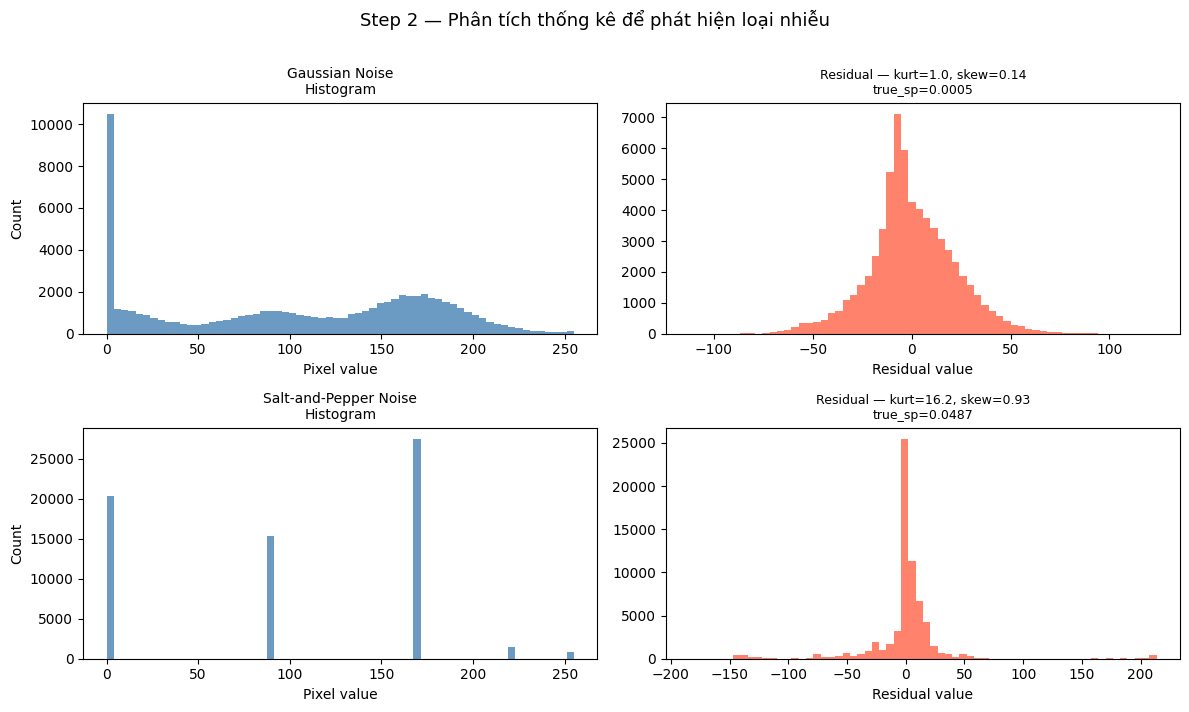

Saved: step2_statistics.png


In [6]:
# ─────────────────────────────────────────────
# Visualize thống kê phân tích
# ─────────────────────────────────────────────

def plot_statistics(noisy, stats, title, ax_hist, ax_res):
    blurred  = cv2.GaussianBlur(noisy.astype(np.float32), (5, 5), 1.0)
    residual = noisy.astype(np.float32) - blurred

    ax_hist.hist(noisy.ravel(), bins=64, range=(0, 255),
                 color="steelblue", alpha=0.8, edgecolor="none")
    ax_hist.set_title(f"{title}\nHistogram", fontsize=10)
    ax_hist.set_xlabel("Pixel value")
    ax_hist.set_ylabel("Count")

    ax_res.hist(residual.ravel(), bins=64, color="tomato", alpha=0.8, edgecolor="none")
    ax_res.set_title(
        f"Residual — kurt={stats['kurtosis']:.1f}, "
        f"skew={stats['skewness']:.2f}\n"
        f"true_sp={stats['true_sp_ratio']:.4f}", fontsize=9)
    ax_res.set_xlabel("Residual value")

fig, axes = plt.subplots(2, 2, figsize=(12, 7))
plot_statistics(noisy_gaussian, stats_g,  "Gaussian Noise",       axes[0][0], axes[0][1])
plot_statistics(noisy_sp,       stats_sp, "Salt-and-Pepper Noise", axes[1][0], axes[1][1])

plt.suptitle("Step 2 — Phân tích thống kê để phát hiện loại nhiễu", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig("step2_statistics.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: step2_statistics.png")

---
## 3. Áp dụng bộ lọc tự động

| Loại nhiễu | Bộ lọc chọn |
|------------|-------------|
| Salt-and-Pepper | **Median Filter** (kernel 3×3) |
| Gaussian | **Bilateral Filter** (d=9, σ=75) — giữ cạnh tốt hơn Gaussian blur |
| Other | Gaussian Blur (5×5, σ=1.0) — fallback |

In [7]:
def apply_filter(gray: np.ndarray, noise_type: str):
    """Chọn và áp dụng bộ lọc phù hợp với loại nhiễu."""
    if noise_type == "salt_and_pepper":
        filtered    = cv2.medianBlur(gray, ksize=3)
        filter_name = "Median Filter (kernel=3×3)"

    elif noise_type == "gaussian":
        filtered    = cv2.bilateralFilter(gray.astype(np.uint8),
                                          d=9, sigmaColor=75, sigmaSpace=75)
        filter_name = "Bilateral Filter (d=9, σColor=75, σSpace=75)"

    else:
        filtered    = cv2.GaussianBlur(gray, (5, 5), 1.0)
        filter_name = "Gaussian Blur (kernel=5×5, σ=1.0) [fallback]"

    return filtered.astype(np.uint8), filter_name


# Áp dụng
filtered_g,  fname_g  = apply_filter(noisy_gaussian, stats_g["noise_type"])
filtered_sp, fname_sp = apply_filter(noisy_sp,       stats_sp["noise_type"])

print(f"Gaussian  → Bộ lọc: {fname_g}")
print(f"S&P       → Bộ lọc: {fname_sp}")

Gaussian  → Bộ lọc: Bilateral Filter (d=9, σColor=75, σSpace=75)
S&P       → Bộ lọc: Median Filter (kernel=3×3)


---
## 4. Tính PSNR & Báo cáo kết quả

In [8]:
def compute_psnr(img_a: np.ndarray, img_b: np.ndarray) -> float:
    """Tính PSNR (dB) giữa hai ảnh uint8 cùng kích thước."""
    mse = np.mean((img_a.astype(np.float64) - img_b.astype(np.float64)) ** 2)
    if mse < 1e-10:
        return float("inf")
    return 10.0 * np.log10(255.0 ** 2 / mse)


def print_report(label, stats, filter_name, psnr_before, psnr_after):
    sep = "═" * 55
    print(f"\n{sep}")
    print(f"  {label}")
    print(sep)
    print(f"  Loại nhiễu phát hiện : {stats['noise_type'].upper()}")
    print(f"  Bộ lọc áp dụng       : {filter_name}")
    print()
    print(f"  outlier_ratio  = {stats['outlier_ratio']:.4f}")
    print(f"  true_sp_ratio  = {stats['true_sp_ratio']:.4f}")
    print(f"  kurtosis       = {stats['kurtosis']:.4f}")
    print(f"  skewness       = {stats['skewness']:.4f}")
    print(f"  mean_diff(med) = {stats['mean_diff']:.4f}")
    print(f"  std_residual   = {stats['std_residual']:.4f}")
    print()
    print(f"  Lý do: {stats['reasoning']}")
    print()
    print(f"  PSNR trước lọc : {psnr_before:6.2f} dB")
    print(f"  PSNR sau lọc   : {psnr_after:6.2f} dB")
    print(f"  Cải thiện      : {psnr_after - psnr_before:+.2f} dB")
    print(sep)


# Tính PSNR
psnr_g_before  = compute_psnr(clean, noisy_gaussian)
psnr_g_after   = compute_psnr(clean, filtered_g)

psnr_sp_before = compute_psnr(clean, noisy_sp)
psnr_sp_after  = compute_psnr(clean, filtered_sp)

# In báo cáo
print_report("TEST 1 — GAUSSIAN NOISE",       stats_g,  fname_g,  psnr_g_before,  psnr_g_after)
print_report("TEST 2 — SALT-AND-PEPPER NOISE", stats_sp, fname_sp, psnr_sp_before, psnr_sp_after)


═══════════════════════════════════════════════════════
  TEST 1 — GAUSSIAN NOISE
═══════════════════════════════════════════════════════
  Loại nhiễu phát hiện : GAUSSIAN
  Bộ lọc áp dụng       : Bilateral Filter (d=9, σColor=75, σSpace=75)

  outlier_ratio  = 0.1489
  true_sp_ratio  = 0.0005
  kurtosis       = 0.9636
  skewness       = 0.1408
  mean_diff(med) = 15.6883
  std_residual   = 21.9166

  Lý do: kurtosis=0.96 ∈ (-3.5, 3.5) và skewness=0.14 ∈ (-1, 1) → Gaussian

  PSNR trước lọc :  20.86 dB
  PSNR sau lọc   :  29.19 dB
  Cải thiện      : +8.33 dB
═══════════════════════════════════════════════════════

═══════════════════════════════════════════════════════
  TEST 2 — SALT-AND-PEPPER NOISE
═══════════════════════════════════════════════════════
  Loại nhiễu phát hiện : SALT_AND_PEPPER
  Bộ lọc áp dụng       : Median Filter (kernel=3×3)

  outlier_ratio  = 0.3237
  true_sp_ratio  = 0.0487
  kurtosis       = 16.1713
  skewness       = 0.9288
  mean_diff(med) = 8.5266
  std_re

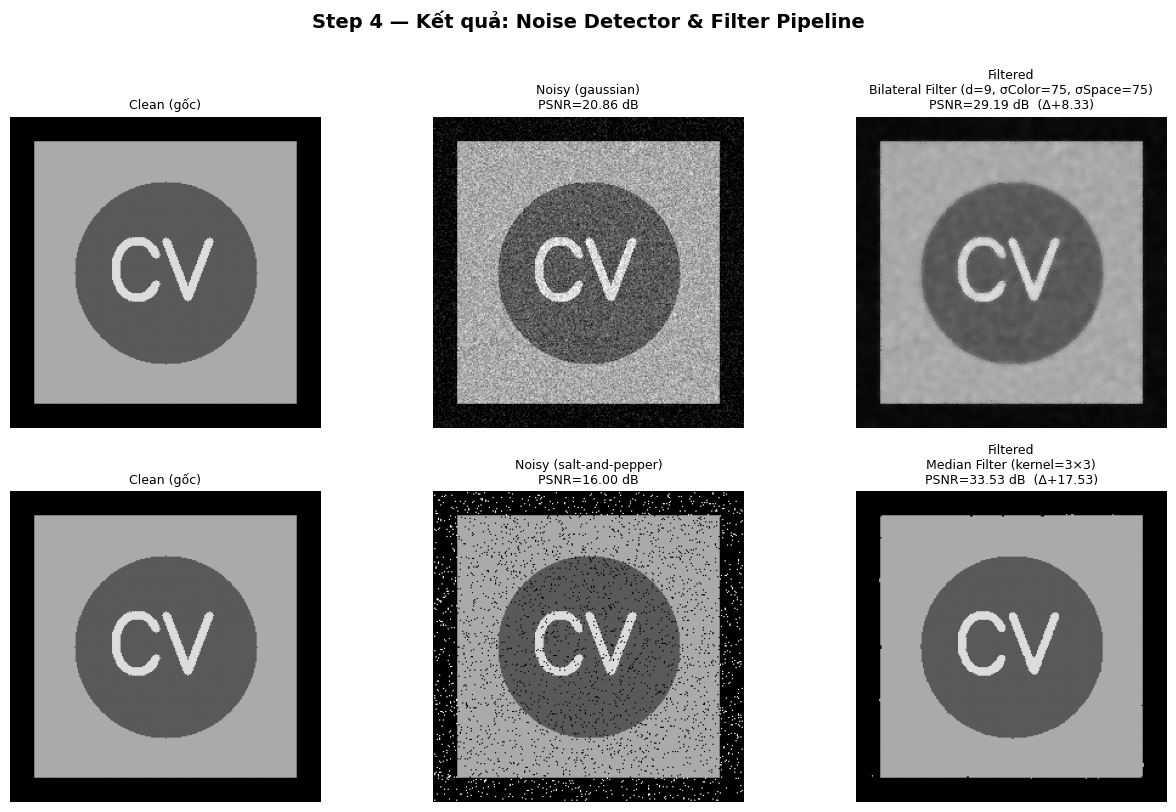

Saved: step4_results.png


In [9]:
# ─────────────────────────────────────────────
# Visualization kết quả cuối
# ─────────────────────────────────────────────

def plot_pipeline(clean, noisy, filtered, noise_type, filter_name,
                  psnr_before, psnr_after, row_title, axes_row):
    imgs   = [clean, noisy, filtered]
    titles = [
        "Clean (gốc)",
        f"Noisy ({noise_type.replace('_','-')})\nPSNR={psnr_before:.2f} dB",
        f"Filtered\n{filter_name}\nPSNR={psnr_after:.2f} dB  (Δ{psnr_after-psnr_before:+.2f})"
    ]
    for ax, img, title in zip(axes_row, imgs, titles):
        ax.imshow(img, cmap="gray", vmin=0, vmax=255)
        ax.set_title(title, fontsize=9)
        ax.axis("off")
    axes_row[0].set_ylabel(row_title, fontsize=11, fontweight="bold", labelpad=8)


fig, axes = plt.subplots(2, 3, figsize=(13, 8))

plot_pipeline(clean, noisy_gaussian, filtered_g,
              stats_g["noise_type"],  fname_g,
              psnr_g_before,  psnr_g_after,
              "Gaussian", axes[0])

plot_pipeline(clean, noisy_sp, filtered_sp,
              stats_sp["noise_type"], fname_sp,
              psnr_sp_before, psnr_sp_after,
              "Salt-and-Pepper", axes[1])

plt.suptitle("Step 4 — Kết quả: Noise Detector & Filter Pipeline",
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("step4_results.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: step4_results.png")

---
## 5. Thử với ảnh thực (tuỳ chọn)

Thay `"your_image.png"` bằng đường dẫn ảnh thực của bạn.


═══════════════════════════════════════════════════════
  File        : clean_sp.png
  Noise type  : SALT_AND_PEPPER
  Filter      : Median Filter (kernel=3×3)
  PSNR before : 18.02 dB
  PSNR after  : 29.29 dB  (Δ+11.27)
═══════════════════════════════════════════════════════
  Saved: clean_sp_filtered.png


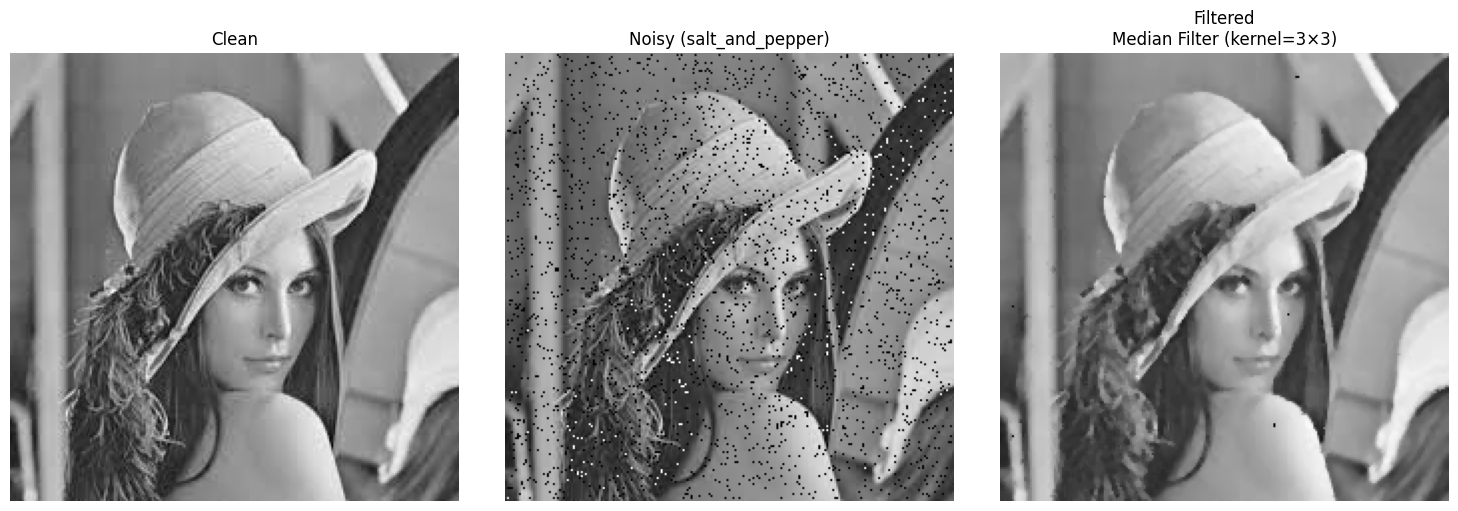

Hàm full_pipeline() đã sẵn sàng — uncomment các dòng trên để chạy với ảnh thực.


In [12]:
# ─────────────────────────────────────────────
# Pipeline hoàn chỉnh cho ảnh thực
# ─────────────────────────────────────────────

def full_pipeline(noisy_path: str, reference_path: str = None):
    """
    Chạy toàn bộ pipeline trên ảnh từ file:
      noisy_path     : đường dẫn ảnh nhiễu
      reference_path : đường dẫn ảnh sạch (tuỳ chọn, để tính PSNR)
    """
    noisy = cv2.imread(noisy_path, cv2.IMREAD_GRAYSCALE)
    if noisy is None:
        print(f"[LỖI] Không mở được: {noisy_path}")
        return

    reference = None
    if reference_path:
        reference = cv2.imread(reference_path, cv2.IMREAD_GRAYSCALE)

    # Detect → Filter → PSNR
    stats       = detect_noise_type(noisy)
    filtered, filter_name = apply_filter(noisy, stats["noise_type"])

    psnr_before = compute_psnr(reference, noisy)    if reference is not None else None
    psnr_after  = compute_psnr(reference, filtered) if reference is not None else None

    # In báo cáo
    sep = "═" * 55
    print(f"\n{sep}")
    print(f"  File        : {noisy_path}")
    print(f"  Noise type  : {stats['noise_type'].upper()}")
    print(f"  Filter      : {filter_name}")
    if psnr_before:
        print(f"  PSNR before : {psnr_before:.2f} dB")
        print(f"  PSNR after  : {psnr_after:.2f} dB  (Δ{psnr_after-psnr_before:+.2f})")
    print(sep)

    # Lưu kết quả
    out_path = Path(noisy_path).stem + "_filtered.png"
    cv2.imwrite(out_path, filtered)
    print(f"  Saved: {out_path}")

    # Hiển thị
    n_cols = 3 if reference is not None else 2
    fig, axes = plt.subplots(1, n_cols, figsize=(5*n_cols, 5))
    if reference is not None:
        axes[0].imshow(reference, cmap="gray"); axes[0].set_title("Clean"); axes[0].axis("off")
        axes[1].imshow(noisy, cmap="gray");     axes[1].set_title(f"Noisy ({stats['noise_type']})"); axes[1].axis("off")
        axes[2].imshow(filtered, cmap="gray");  axes[2].set_title(f"Filtered\n{filter_name}"); axes[2].axis("off")
    else:
        axes[0].imshow(noisy, cmap="gray");    axes[0].set_title(f"Noisy ({stats['noise_type']})"); axes[0].axis("off")
        axes[1].imshow(filtered, cmap="gray"); axes[1].set_title(f"Filtered\n{filter_name}"); axes[1].axis("off")
    plt.tight_layout()
    plt.show()


# ── Uncomment và thay đường dẫn để dùng ──
# full_pipeline("your_noisy_image.png")                              # không có clean ref
full_pipeline("clean_sp.png", "clean.png")     # có clean ref để tính PSNR

print("Hàm full_pipeline() đã sẵn sàng — uncomment các dòng trên để chạy với ảnh thực.")

---
## Tóm tắt

| | Gaussian | Salt-and-Pepper |
|---|---|---|
| **Phát hiện** | kurtosis thấp + skewness nhỏ | true_sp_ratio > 0.02 |
| **Bộ lọc** | Bilateral Filter | Median Filter |
| **PSNR** | cải thiện đáng kể | cải thiện đáng kể |